<a href="https://colab.research.google.com/github/Lok-Tung/Just-for-fun/blob/main/product-description-generation/Product_Description_Generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -U datasets==2.14.6

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 493.7/493.7 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 16.4 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 

In [28]:
!pip install evaluate
!pip install bert_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 478.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 20.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin

In [1]:
import torch
from datasets import load_dataset
from transformers import BlipProcessor, BlipForConditionalGeneration, TrainingArguments, Trainer
from torch.utils.data import Dataset
from PIL import Image
import os

# Check GPU
print("CUDA available:", torch.cuda.is_available())

CUDA available: True


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


dict_keys(['image', 'Uniq Id', 'Product Name', 'Category', 'Selling Price', 'Model Number', 'About Product', 'Product Specification', 'Technical Details', 'Shipping Weight', 'Variants', 'Product Url', 'Is Amazon Seller', 'description'])
Title: Kurio Glow Smartwatch for Kids with Bluetooth, Apps, Camera & Games, Blue
Description: Kurio Glow Smartwatch: Fun, Safe & Educational!  This kids' smartwatch boasts Bluetooth connectivity, built-in apps & games, and a camera – all in a vibrant blue design. Perfect for learning & play!  #kidssmartwatch #kidselectronics #educationaltoys #kurioglow


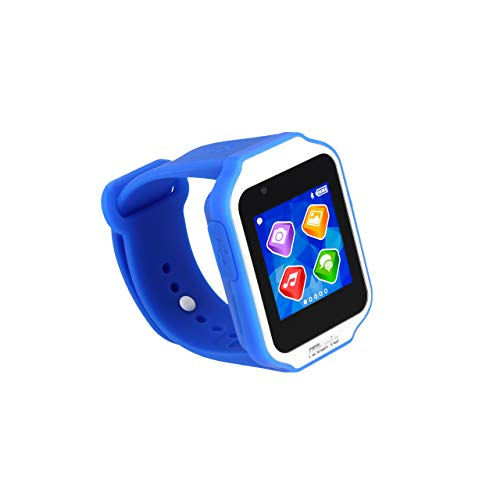

In [2]:
# ============================================
# 📦 2. Load the Dataset
# ============================================
dataset = load_dataset("philschmid/amazon-product-descriptions-vlm", split="train")
split = dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = split['train']
test_dataset = split['test']

# Preview one sample
sample = dataset[0]
print(sample.keys())
print("Title:", sample['Product Name'])
print("Description:", sample['description'])
sample['image']


In [3]:
# ============================================
# 🧹 3. Dataset Wrapper for Trainer
# ============================================
class ProductDescriptionDataset(Dataset):
    def __init__(self, hf_dataset, processor, max_length=128):
        self.dataset = hf_dataset
        self.processor = processor
        self.max_length = max_length

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        image = item['image']
        caption = item['description']

        # Preprocess image + caption
        inputs = self.processor(images=image,
                                text=caption,
                                padding='max_length',
                                truncation=True,
                                max_length=self.max_length,
                                return_tensors="pt")

        # Flatten for PyTorch DataLoader
        return {
            "input_ids": inputs["input_ids"].squeeze(),
            "attention_mask": inputs["attention_mask"].squeeze(),
            "pixel_values": inputs["pixel_values"].squeeze(),
            "labels": inputs["input_ids"].squeeze()  # teacher forcing
        }

# Load BLIP processor
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
train_dataset = ProductDescriptionDataset(train_dataset, processor)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [4]:
# ============================================
# 🧠 4. Load BLIP Model
# ============================================
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")
model.to("cuda")

BlipForConditionalGeneration(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((768,), eps=1e-0

In [12]:
# ============================================
# ⚙️ 5. Training Configuration
# ============================================
training_args = TrainingArguments(
    output_dir="./blip-product-model",
    per_device_train_batch_size=8,      # batch size per GPU
    num_train_epochs=5,
    learning_rate=5e-5,
    weight_decay=0.01,
    save_strategy="epoch",              # save model checkpoint each epoch
    logging_dir="./logs",
    logging_strategy="steps",
    logging_steps=50,
    report_to=[],
    fp16=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    tokenizer=processor.tokenizer,
)

/tmp/ipython-input-12-1776868679.py:18: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [13]:
# ============================================
# 🚀 6. Train!
# ============================================
trainer.train()

Step,Training Loss
50,6.190400
100,2.442500
150,1.417600
200,1.034800
250,1.001000
300,0.810600
350,0.662600
400,0.669300
450,0.473700
500,0.454700


TrainOutput(global_step=675, training_loss=1.2143847444322373, metrics={'train_runtime': 1177.4888, 'train_samples_per_second': 4.569, 'train_steps_per_second': 0.573, 'total_flos': 3.192619248970629e+18, 'train_loss': 1.2143847444322373, 'epoch': 5.0})

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



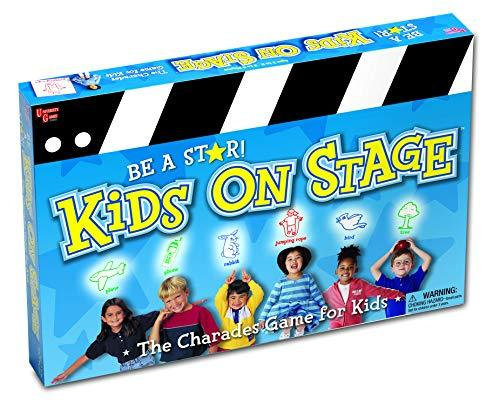


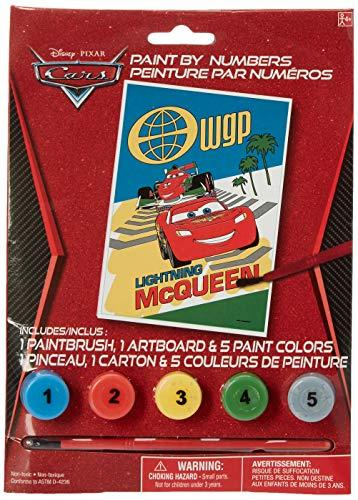


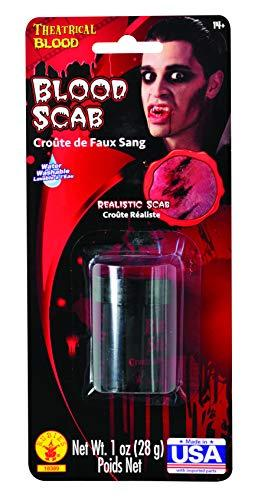


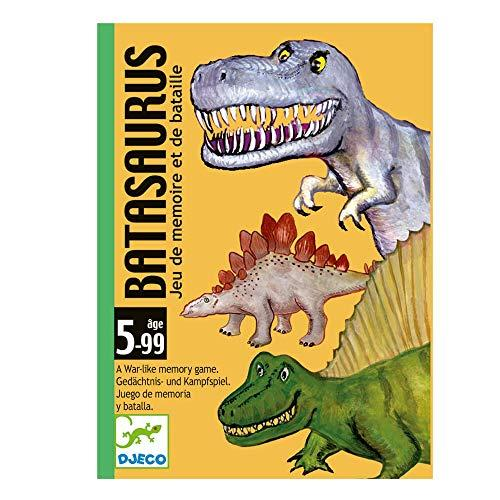


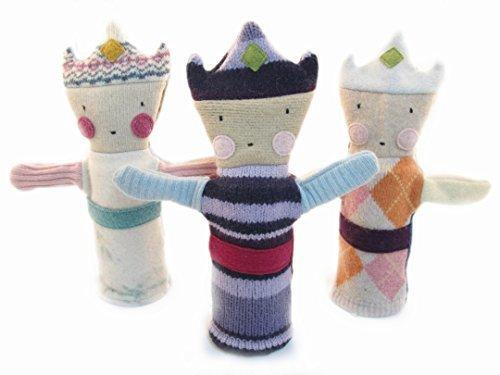


✅ Average BERTScore F1 over 5 samples: 0.8662


In [18]:
from IPython.display import display, HTML
import base64
from io import BytesIO
from evaluate import load
import numpy as np

def display_image_with_captions(image, ground_truth, generated, bert_score_f1, idx):
    # Convert PIL Image to base64 string
    buffered = BytesIO()
    image.save(buffered, format="JPEG")
    img_str = base64.b64encode(buffered.getvalue()).decode()

    # Format score as a percentage with color
    score_color = "green" if bert_score_f1 > 0.85 else "orange" if bert_score_f1 > 0.75 else "red"
    score_html = f'<span style="color:{score_color}; font-weight: bold;">{bert_score_f1:.4f}</span>'

    html = f"""
    <div style="display: flex; align-items: center; margin-bottom: 20px;">
        <img src="data:image/jpeg;base64,{img_str}" width="300" style="margin-right: 25px;" />
        <div style="max-width: 600px;">
            <p><b>Sample #{idx}</b></p>
            <p><b>Ground Truth:</b> {ground_truth}</p>
            <p><b>Generated:</b> {generated}</p>
            <p><b>BERTScore F1:</b> {score_html}</p>
        </div>
    </div>
    """
    display(HTML(html))


# Load BERTScore
bertscore = load("bertscore")

# Initialize lists
generated_captions = []
reference_captions = []
bert_scores = []

model.eval()
for i in range(5):  # Adjust number as needed
    sample = test_dataset[i]
    image = sample["image"]
    gt_caption = sample["description"]

    # Generate
    inputs = processor(images=image, return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = model.generate(**inputs, max_length=64)
        gen_caption = processor.decode(outputs[0], skip_special_tokens=True)

    # Compute BERTScore
    results = bertscore.compute(predictions=[gen_caption], references=[gt_caption], lang="en")
    score = float(np.mean(results["f1"]))
    bert_scores.append(score)

    # Store results
    generated_captions.append(gen_caption)
    reference_captions.append(gt_caption)

    # Display
    display_image_with_captions(image, gt_caption, gen_caption, score, i)

# Overall average
avg_score = np.mean(bert_scores)
print(f"\n✅ Average BERTScore F1 over {len(bert_scores)} samples: {avg_score:.4f}")
